# Step 1: Data Exploration
Goal: Understand what data we have for the 16 PMData participants.

In [1]:
import os
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = '/home/fallen/Projects/Main_Project/backend/Data'
users = [f'p{i:02d}' for i in range(1, 17)]
print(f"Found {len(users)} users.")

Found 16 users.


### Data Availability Matrix
Let's see which files exist for which users.

Saved data_availability.png


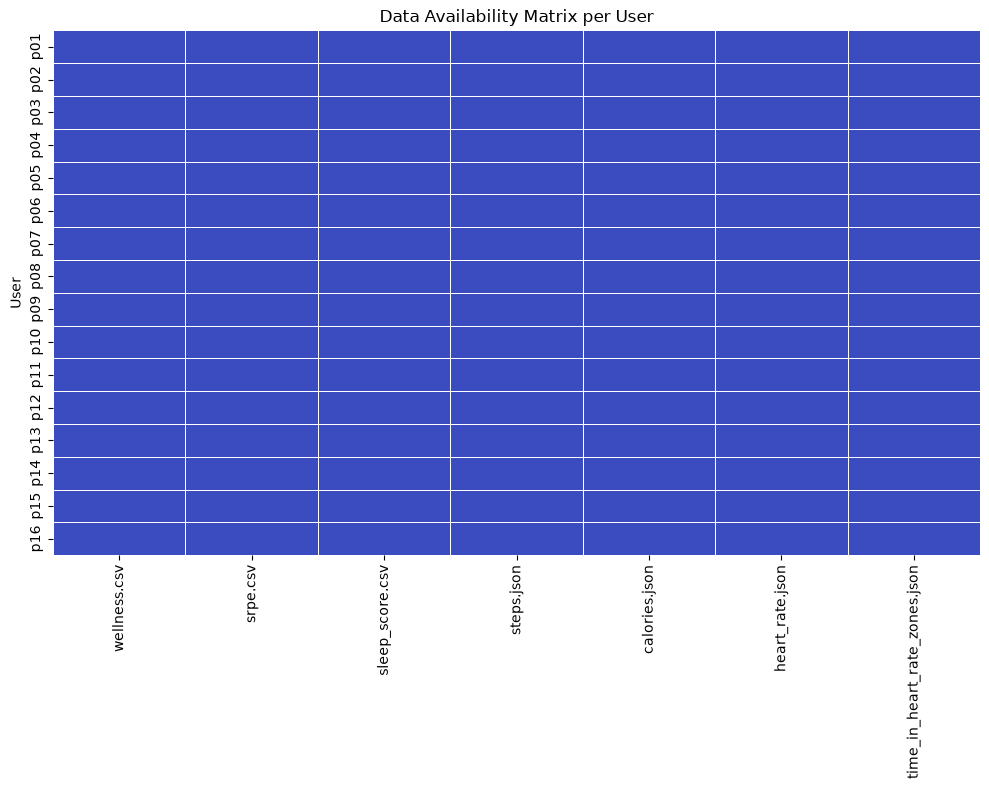

In [2]:
files_to_check = [
    'pmsys/wellness.csv',
    'pmsys/srpe.csv',
    'fitbit/sleep_score.csv',
    'fitbit/steps.json',
    'fitbit/calories.json',
    'fitbit/heart_rate.json',
    'fitbit/time_in_heart_rate_zones.json'
]

availability = []
for user in users:
    user_data = {'User': user}
    for file in files_to_check:
        path = os.path.join(base_dir, user, file)
        user_data[file.split('/')[-1]] = os.path.exists(path)
    availability.append(user_data)

avail_df = pd.DataFrame(availability).set_index('User')
plt.figure(figsize=(10, 8))
sns.heatmap(avail_df, cmap='coolwarm', cbar=False, linewidths=0.5)
plt.title('Data Availability Matrix per User')
plt.tight_layout()
plt.savefig('/home/fallen/Projects/Main_Project/research/figures/data_availability.png')
print("Saved data_availability.png")
# plt.show() # Commented out for headless execution

### Mood Distribution Analysis
We need to check if the mood scores (1-7) are imbalanced.

/tmp/ipykernel_203802/2027394280.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=wellness_df, x='mood', palette='viridis')


Saved mood_distribution.png


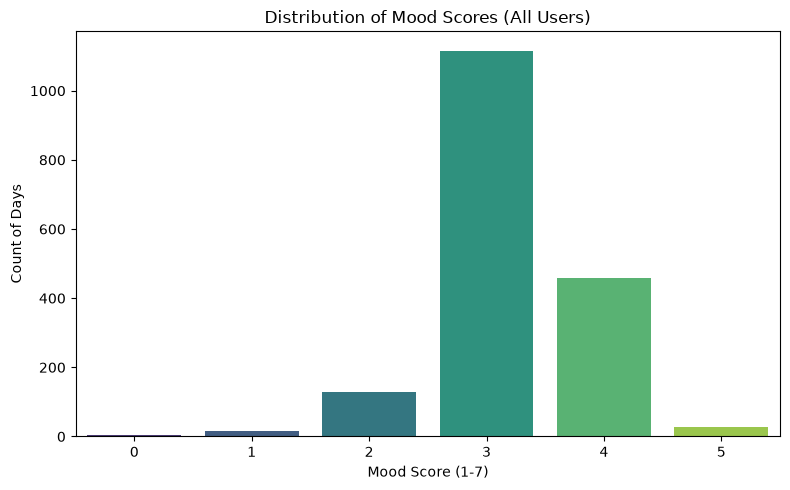

In [3]:
all_wellness = []
for user in users:
    path = os.path.join(base_dir, user, 'pmsys/wellness.csv')
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['User'] = user
        all_wellness.append(df)

wellness_df = pd.concat(all_wellness, ignore_index=True)
wellness_df['Date'] = pd.to_datetime(wellness_df['effective_time_frame']).dt.date

plt.figure(figsize=(8, 5))
sns.countplot(data=wellness_df, x='mood', palette='viridis')
plt.title('Distribution of Mood Scores (All Users)')
plt.xlabel('Mood Score (1-7)')
plt.ylabel('Count of Days')
plt.tight_layout()
plt.savefig('/home/fallen/Projects/Main_Project/research/figures/mood_distribution.png')
print("Saved mood_distribution.png")

### Correlation Analysis
Let's see how wellness features correlate with each other.

Saved correlation_heatmap.png


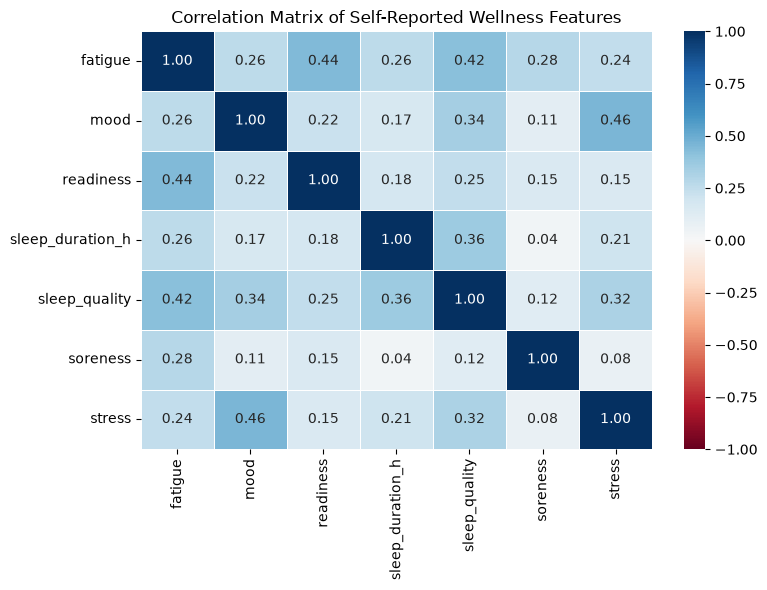

In [4]:
wellness_features = ['fatigue', 'mood', 'readiness', 'sleep_duration_h', 'sleep_quality', 'soreness', 'stress']
corr_df = wellness_df[wellness_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap='RdBu', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Self-Reported Wellness Features')
plt.tight_layout()
plt.savefig('/home/fallen/Projects/Main_Project/research/figures/correlation_heatmap.png')
print("Saved correlation_heatmap.png")

### Missing Values Check
Which features are missing the most data?

In [5]:
missing_data = wellness_df[wellness_features].isnull().sum() / len(wellness_df) * 100
print("\nPercentage of missing data per feature:")
print(missing_data.sort_values(ascending=False))


Percentage of missing data per feature:
fatigue             0.0
mood                0.0
readiness           0.0
sleep_duration_h    0.0
sleep_quality       0.0
soreness            0.0
stress              0.0
dtype: float64
